# Hola! 😀

Soy **Jaime Paz** y mis amigos me suelen llamar James! – *"Tranquilo, no juego en el Real Madrid"* ⚽😅. Sí, como el futbolista James Rodríguez, pero en versión científico de datos… y mejor no me digas como a él. 😉

Como tu revisor en TripleTen, estoy aquí para ayudarte a pulir tu código y tu forma de trabajar con datos. Si algo necesita un ajuste, no te preocupes: la idea es que cada comentario te acerque más a cómo se trabaja en un entorno profesional y que tu proyecto brille con todo su potencial.

Cada vez que encuentre un detalle importante en tu notebook, te lo señalaré para que puedas corregirlo y seguir creciendo. Si en algún punto no logras resolver algo, también estoy para guiarte en próximos intentos de revisión. 🔁

Es muy importante que, cuando veas mis comentarios en el notebook, **no los muevas, no los modifiques y no los borres**. Así mantenemos un historial claro de lo que ya revisamos y de tus avances. ✅

---

### Formato de Comentarios

Revisaré cuidadosamente tu notebook para asegurar que cumpla con los requisitos y te daré comentarios usando el siguiente formato:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Éxito</b> ✅ - ¡Excelente trabajo! Esta parte está bien implementada y contribuye de forma positiva al análisis o al proyecto. Sigue aplicando estas buenas prácticas en las siguientes secciones.
    
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Atención</b> ⚠️ - Esta parte del código funciona, pero se puede mejorar u optimizar. Tal vez sea más claro, más eficiente o más fácil de mantener. Te señalaré ideas para que puedas reforzar esta sección.
    
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>A resolver</b> ❗ - Aquí hay un problema o error que es necesario corregir para aprobar esta parte. Revisa el comentario con calma, ajústalo y vuelve a intentarlo; es clave para la validez del análisis y la precisión de los resultados.
    
</div>

---

Al final de cada revisión, recibirás un **Comentario General del Revisor** que incluirá:

- **Aspectos positivos:** Un resumen de los puntos fuertes de tu proyecto. 💪
- **Áreas de mejora:** Sugerencias claras sobre lo que puedes reforzar. 💡
- **Temas adicionales para investigar:** Ideas opcionales que puedes explorar por tu cuenta para seguir creciendo.

Estos temas adicionales no son obligatorios ahora, pero pueden ayudarte a profundizar en el futuro. 📚

---

Si tienes dudas o quieres responder a un comentario específico, puedes usar este formato:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>
    
Aquí puedes escribir tu respuesta o pregunta sobre el comentario.
    
</div>

**¡Empecemos!** 🚀

<div class="alert alert-block alert-success">

<b>Comentario del revisor</b> <a class="tocSkip"></a><br>

    

<b>Éxito</b> ✅ - ¡Excelente trabajo! Tu proyecto es excepcional y has logrado corregir los pequeños detalles pendientes. Abajo he dejado mis comentarios y unas recomendaciones que debemos mejorar en tus futuros proyectos. Recuerda, todo insight encontrado debe estar siempre respaldado por una prueba estadística y te hagan ¡un máster en Data!

¡Felicidades!    

</div>



# Proyecto 12 - Análisis del comportamiento de usuarios.

In [58]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

### Limpieza y corrección de datos.

In [27]:
logs = pd.read_csv('/datasets/logs_exp_us.csv', sep='\t')

In [3]:
logs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


In [12]:
print(logs.head())

                 EventName         DeviceIDHash  EventTimestamp  ExpId
0         MainScreenAppear  4575588528974610257      1564029816    246
1         MainScreenAppear  7416695313311560658      1564053102    246
2  PaymentScreenSuccessful  3518123091307005509      1564054127    248
3         CartScreenAppear  3518123091307005509      1564054127    248
4  PaymentScreenSuccessful  6217807653094995999      1564055322    248


In [28]:
logs.columns = logs.columns.str.strip().str.lower().str.replace("_", " ")
print(logs.columns)

Index(['eventname', 'deviceidhash', 'eventtimestamp', 'expid'], dtype='object')


In [29]:
logs['datetime'] = pd.to_datetime(logs['eventtimestamp'], unit='s') 
logs['date'] = logs['datetime'].dt.date

print(logs.head())

                 eventname         deviceidhash  eventtimestamp  expid  \
0         MainScreenAppear  4575588528974610257      1564029816    246   
1         MainScreenAppear  7416695313311560658      1564053102    246   
2  PaymentScreenSuccessful  3518123091307005509      1564054127    248   
3         CartScreenAppear  3518123091307005509      1564054127    248   
4  PaymentScreenSuccessful  6217807653094995999      1564055322    248   

             datetime        date  
0 2019-07-25 04:43:36  2019-07-25  
1 2019-07-25 11:11:42  2019-07-25  
2 2019-07-25 11:28:47  2019-07-25  
3 2019-07-25 11:28:47  2019-07-25  
4 2019-07-25 11:48:42  2019-07-25  


### Estudiar y comprobar los datos

##### Eventos en el registro.

In [30]:
events_uniq = logs['eventname'].unique()
print(f"Eventos unicos {events_uniq}")
print("Numero de eventos en el registro:", logs['eventname'].nunique())

Eventos unicos ['MainScreenAppear' 'PaymentScreenSuccessful' 'CartScreenAppear'
 'OffersScreenAppear' 'Tutorial']
Numero de eventos en el registro: 5


##### Usuarios en el registro.

In [31]:
usuarios_uniq = logs['deviceidhash'].nunique()
print("Numero de usuarios en el registro:", usuarios_uniq)

Numero de usuarios en el registro: 7551


##### Promedio de eventos por usuario.

In [32]:
total_eventos = len(logs)
promedio = total_eventos / usuarios_uniq 
print("Promedio de eventos por usuario:", promedio)

Promedio de eventos por usuario: 32.33028737915508


##### ¿Qué periodo de tiempo cubren los datos?

In [33]:
date_max = logs['date'].max()
date_min = logs['date'].min()
print(f"Fecha maxima del registro {date_max} y fecha minima {date_min}")

Fecha maxima del registro 2019-08-07 y fecha minima 2019-07-25


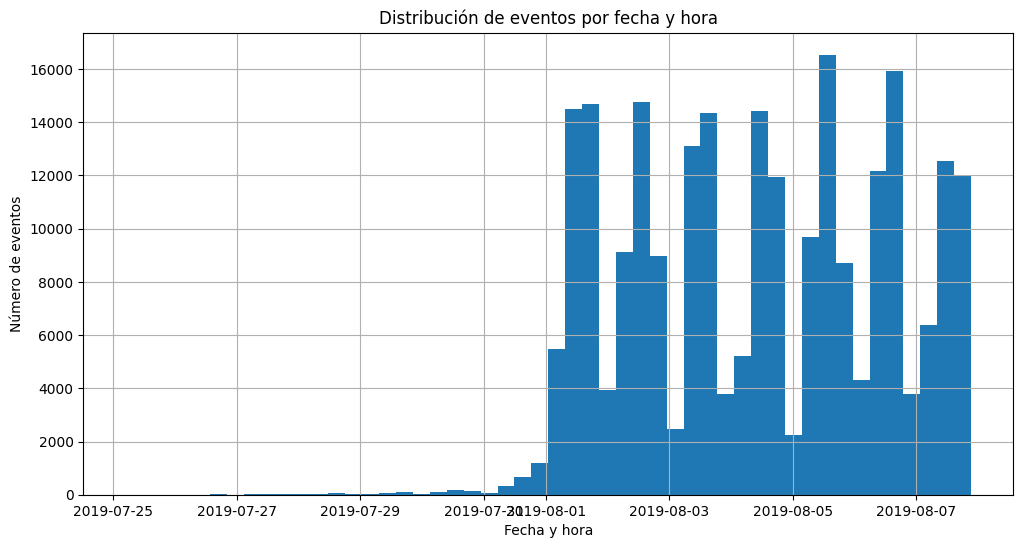

In [34]:
plt.figure(figsize=(12, 6))
logs['datetime'].hist(bins=50)
plt.title('Distribución de eventos por fecha y hora')
plt.xlabel('Fecha y hora')
plt.ylabel('Número de eventos')
plt.show()

In [35]:
eventos_por_dia = logs.groupby('date').size()
print("Eventos por día:")
print(eventos_por_dia)

Eventos por día:
date
2019-07-25        9
2019-07-26       31
2019-07-27       55
2019-07-28      105
2019-07-29      184
2019-07-30      413
2019-07-31     2031
2019-08-01    36229
2019-08-02    35606
2019-08-03    33351
2019-08-04    33033
2019-08-05    36113
2019-08-06    35822
2019-08-07    31144
dtype: int64


In [36]:
fecha_inicio_completos = '2019-08-01'

logs_completos = logs[logs['date'] >= pd.to_datetime(fecha_inicio_completos).date()]

print(f"Datos originales: {len(logs)} eventos")
print(f"Datos completos: {len(logs_completos)} eventos")
print(f"Período de datos completos: {logs_completos['date'].min()} a {logs_completos['date'].max()}")

Datos originales: 244126 eventos
Datos completos: 241298 eventos
Período de datos completos: 2019-08-01 a 2019-08-07


##### Podemos observar que los primeros 3 días tienen muchos datos incompletos; a partir del cuarto dia podemos ver que los datos pasan a estar en transicion pero el dia primero de agosto los datos pasan a estar completos estos son las datos que vamos a usar.

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Atención</b> ⚠️ - Buen inicio: cargaste los datos, convertiste timestamps y filtraste el periodo útil (a partir del 2019-08-01), y la gráfica de distribución respalda esa decisión visualmente. Sin embargo, al renombrar columnas usaste espacios en lugar de snake_case; es mejor usar guiones bajos para evitar problemas posteriores (ejemplo, event_name). Además conviene convertir device id a string y expid a categoría explícita, y comprobar/eliminar duplicados antes del filtrado. ✅
    
</div>

##### Datos de usuarios perdidos.

In [37]:
usuarios_originales = logs['deviceidhash'].nunique()
usuarios_completos = logs_completos['deviceidhash'].nunique()

print(f"Usuarios originales: {usuarios_originales}")
print(f"Usuarios en datos completos: {usuarios_completos}")
print(f"Usuarios perdidos: {usuarios_originales - usuarios_completos}")
print(f"Porcentaje de usuarios perdidos: {((usuarios_originales - usuarios_completos) / usuarios_originales) * 100:.2f}%")

Usuarios originales: 7551
Usuarios en datos completos: 7534
Usuarios perdidos: 17
Porcentaje de usuarios perdidos: 0.23%


##### Verificar usuarios existentes en los 3 grupos

In [38]:
grupos_experimentales = logs_completos['expid'].unique()
print(f"Grupos experimentales únicos: {grupos_experimentales}")
print(f"Número de grupos: {len(grupos_experimentales)}")

usuarios_por_grupo = logs_completos.groupby('expid')['deviceidhash'].nunique()
print("\nUsuarios por grupo experimental:")
print(usuarios_por_grupo)

Grupos experimentales únicos: [246 247 248]
Número de grupos: 3

Usuarios por grupo experimental:
expid
246    2484
247    2513
248    2537
Name: deviceidhash, dtype: int64


### Embudo de eventos

#### Frecuencia de eventos.

In [39]:
frecuencia_eventos = logs_completos['eventname'].value_counts()
print("Eventos ordenados por frecuencia:")
print(frecuencia_eventos)

Eventos ordenados por frecuencia:
MainScreenAppear           117431
OffersScreenAppear          46350
CartScreenAppear            42365
PaymentScreenSuccessful     34113
Tutorial                     1039
Name: eventname, dtype: int64


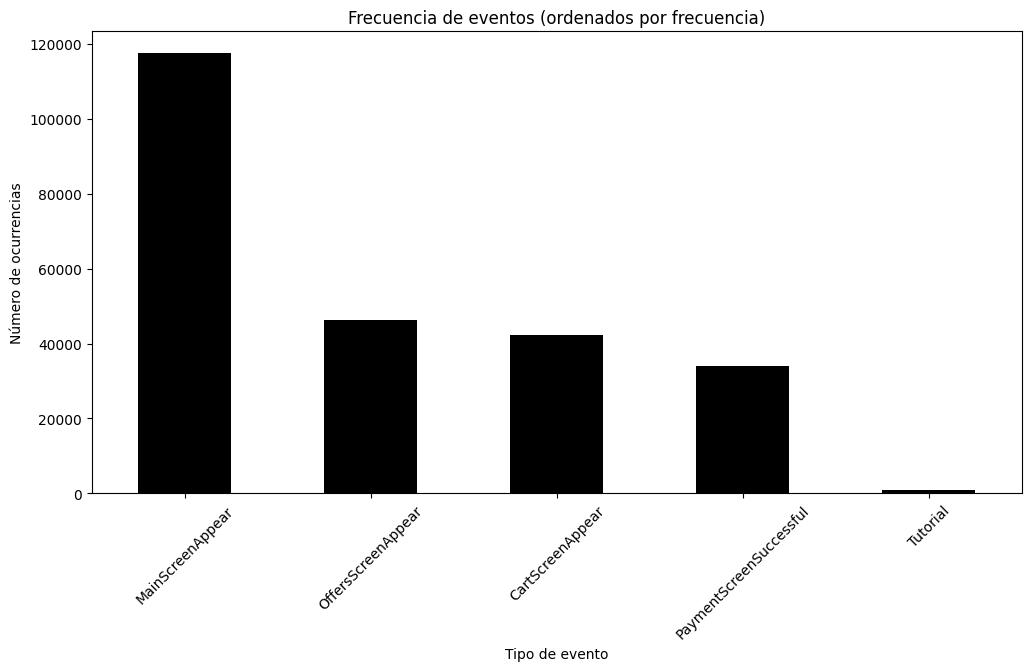

In [40]:
plt.figure(figsize=(12, 6))
frecuencia_eventos.plot(kind='bar', color='black')
plt.title('Frecuencia de eventos (ordenados por frecuencia)')
plt.xlabel('Tipo de evento')
plt.ylabel('Número de ocurrencias')
plt.xticks(rotation=45)
plt.show()

##### Podemos ver que en el evento MainScreenAppear tienen más del doble de visualizaciones que el que le sigue y en los siguientes casos son consistentes hasta el último de estos, que es el Tutorial; este tiene muy poca frecuencia; esto puede deberse a que muchas personas abren la página, pero pocas completan el tutorial, algo positivo que podemos rescatar es que las emtradas a la pagina de pago son altas.

### Cantidad de usuarios que realizaron cada una de las acciones o al menos una acción.

In [41]:
usuarios_por_evento = logs_completos.groupby('eventname')['deviceidhash'].nunique().sort_values(ascending=False)
print("Usuarios únicos por evento (ordenados por cantidad):")
print(usuarios_por_evento)

Usuarios únicos por evento (ordenados por cantidad):
eventname
MainScreenAppear           7419
OffersScreenAppear         4593
CartScreenAppear           3734
PaymentScreenSuccessful    3539
Tutorial                    840
Name: deviceidhash, dtype: int64


In [42]:
total_usuarios = logs_completos['deviceidhash'].nunique()
print(f"Total de usuarios únicos: {total_usuarios}")

proporciones = (usuarios_por_evento / total_usuarios * 100).round(2)
print("Proporción de usuarios que realizaron cada acción:")
for evento, proporcion in proporciones.items():
    print(f"{evento}: {proporcion}% ({usuarios_por_evento[evento]} usuarios)")

Total de usuarios únicos: 7534
Proporción de usuarios que realizaron cada acción:
MainScreenAppear: 98.47% (7419 usuarios)
OffersScreenAppear: 60.96% (4593 usuarios)
CartScreenAppear: 49.56% (3734 usuarios)
PaymentScreenSuccessful: 46.97% (3539 usuarios)
Tutorial: 11.15% (840 usuarios)


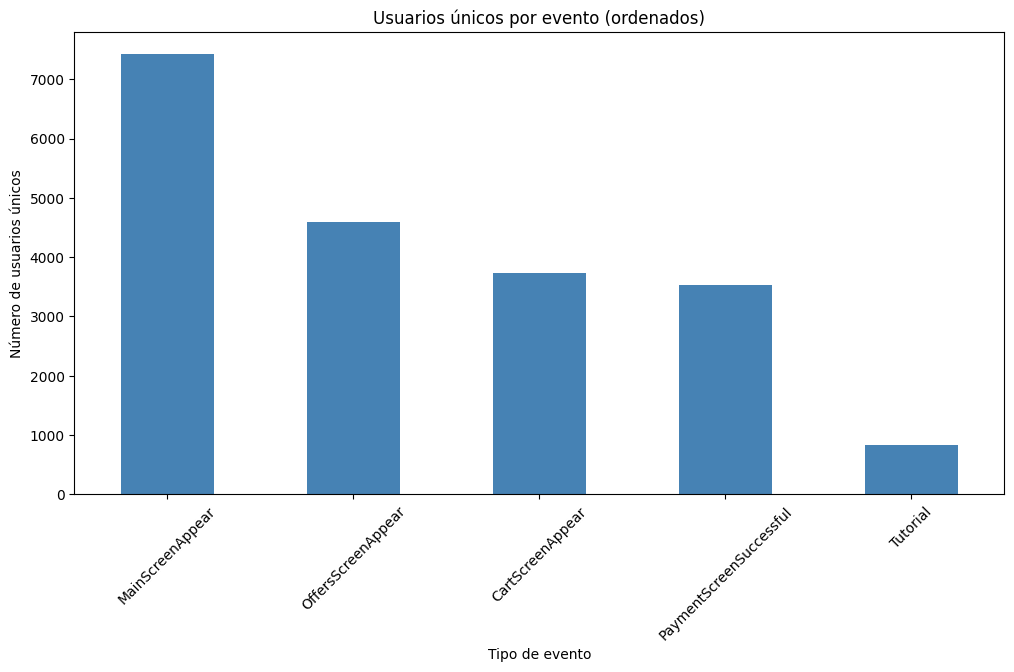

In [43]:
plt.figure(figsize=(12, 6))
usuarios_por_evento.plot(kind='bar', color='steelblue')
plt.title('Usuarios únicos por evento (ordenados)')
plt.xlabel('Tipo de evento')
plt.ylabel('Número de usuarios únicos')
plt.xticks(rotation=45)
plt.show()

##### Como podemos ver, en usuarios únicos y totales siguen el mismo patrón que en la cantidad de eventos: la gente inicia la página; el 47% de estos completan la compra. Esto es una cifra importante; podemos definir que la gente prefiere realizar sus compras sin importar cómo lo hace; es por eso que no completan el tutorial o lo saltan.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Éxito</b> ✅ - Las tablas de frecuencia y el cálculo de usuarios únicos por evento están bien y las gráficas son coherentes con los números impresos. Buen trabajo al cuantificar usuarios perdidos tras el filtrado (0.23%). Como mejora, verifica que ningún usuario aparezca en más de un grupo experimental (chequeo cross-group), y añade etiquetas porcentuales en las gráficas o un funnel visual para comunicar mejor las tasas de conversión. 💡
    
</div>

### ¿En qué orden ocurrieron las acciones?

In [44]:
print("Ejemplo de secuencias de eventos para algunos usuarios:")
sample_users = logs_completos['deviceidhash'].unique()[:5]

for user in sample_users:
    user_events = logs_completos[logs_completos['deviceidhash'] == user].sort_values('eventtimestamp')
    print(f"\nUsuario {user}:")
    print(user_events[['eventname', 'datetime']].head(10))

Ejemplo de secuencias de eventos para algunos usuarios:

Usuario 3737462046622621720:
               eventname            datetime
2828            Tutorial 2019-08-01 00:07:28
2829    MainScreenAppear 2019-08-01 00:08:00
2830    MainScreenAppear 2019-08-01 00:08:55
2831  OffersScreenAppear 2019-08-01 00:08:58
2834  OffersScreenAppear 2019-08-01 00:10:26
2835    MainScreenAppear 2019-08-01 00:10:47
2836    MainScreenAppear 2019-08-01 00:11:10
2837    MainScreenAppear 2019-08-01 00:11:20
2841            Tutorial 2019-08-01 00:12:18
2842    MainScreenAppear 2019-08-01 00:12:34

Usuario 1433840883824088890:
              eventname            datetime
2832   MainScreenAppear 2019-08-01 00:08:59
2877   MainScreenAppear 2019-08-01 00:23:55
2896   MainScreenAppear 2019-08-01 00:25:17
2908   MainScreenAppear 2019-08-01 00:27:54
2909   MainScreenAppear 2019-08-01 00:29:31
2922   MainScreenAppear 2019-08-01 00:33:26
2933   MainScreenAppear 2019-08-01 00:35:57
2934   MainScreenAppear 2019-08-01 00

##### El orden de eventos es el siguiente:
- MainScreenAppear
- OffersScreenAppear 
- CartScreenAppear
- PaymentScreenSuccessful
- Tutorial 
##### Podemos decir que esto es parte de una secuencia, ya que la gente realiza sus compras en el mismo orden.
##### Esto no nos dice mucho, pero sí podemos decir que es un patrón.

### Embudo de eventos (para encontrar la proporción de usuarios que pasan de un evento a otro)

In [47]:
conversion_main_to_offers = (usuarios_por_evento['OffersScreenAppear'] / usuarios_por_evento['MainScreenAppear']) * 100
conversion_offers_to_cart = (usuarios_por_evento['CartScreenAppear'] / usuarios_por_evento['OffersScreenAppear']) * 100
conversion_cart_to_payment = (usuarios_por_evento['PaymentScreenSuccessful'] / usuarios_por_evento['CartScreenAppear']) * 100

print("Conversiones del embudo:")
print(f"MainScreen a OffersScreen: {conversion_main_to_offers:.2f}%")
print(f"OffersScreen a CartScreen: {conversion_offers_to_cart:.2f}%")
print(f"CartScreen a PaymentSuccessful: {conversion_cart_to_payment:.2f}%")

Conversiones del embudo:
MainScreen a OffersScreen: 61.91%
OffersScreen a CartScreen: 81.30%
CartScreen a PaymentSuccessful: 94.78%


##### Podemos ver que el embudo de eventos tiene datos muy positivos; la pérdida de usuarios por evento es cada vez menor entre más se avanza. Esto nos dice que la página tiene factores muy positivos, pero aun así hay factores a mejorar para subir del 60% de la pantalla de inicio a algo mayor.

### ¿En qué etapa se pierden más usuarios?

In [49]:
perdida_main_to_offers = 100 - conversion_main_to_offers

perdida_offers_to_cart = 100 - conversion_offers_to_cart
perdida_cart_to_payment = 100 - conversion_cart_to_payment

print("Pérdidas de usuarios en cada etapa:")
print(f"MainScreen a OffersScreen: {perdida_main_to_offers:.2f}%")
print(f"OffersScreen a CartScreen: {perdida_offers_to_cart:.2f}%")
print(f"CartScreen a PaymentSuccessful: {perdida_cart_to_payment:.2f}%")

Pérdidas de usuarios en cada etapa:
MainScreen a OffersScreen: 38.09%
OffersScreen a CartScreen: 18.70%
CartScreen a PaymentSuccessful: 5.22%


##### Podemos observar que la mayor pérdida es al inicio del embudo, pero entre más avanza menor es la perdida, esto es algo muy positivo pero siempre hay oportunidad de mejora.

### Conversion total de los eventos.

In [48]:
conversion_total = (usuarios_por_evento['PaymentScreenSuccessful'] / usuarios_por_evento['MainScreenAppear']) * 100
print(f"\nConversión total (MainScreen → Payment): {conversion_total:.2f}%")


Conversión total (MainScreen → Payment): 47.70%


##### Con esto podemos ver una cifra que no es del todo positiva, ya que menos del 50% de usuarios que entran a la página completan su compra. Es necesario hacer algo al respecto para que este número suba ofertas o una forma más rápida de realizar la compra, y claro, podemos realizar algún ajuste a la página para que esta sea más amigable para todos los usuarios.

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Atención</b> ⚠️ - Mostrar secuencias de eventos para usuarios reales ayuda a entender el flujo; ordenaste correctamente por timestamp. Ten en cuenta que usar los primeros 5 usuarios es sólo ilustrativo: para afirmar una secuencia robusta conviene computar, por usuario, el primer timestamp de cada evento y luego analizar la frecuencia de esos órdenes (o construir un funnel por primer evento por usuario). Esto evitará inferencias basadas en casos atípicos. 🚀
    
</div>

### Estudiar los resultados del experimento

##### Usuarios por grupo.

In [50]:
total_usuarios_exp = usuarios_por_grupo.sum()
proporciones_grupos = (usuarios_por_grupo / total_usuarios_exp * 100).round(2)

print("Distribución de usuarios por grupo experimental:")
for grupo, usuarios in usuarios_por_grupo.items():
    proporcion = proporciones_grupos[grupo]
    print(f"Grupo {grupo}: {usuarios} usuarios ({proporcion}%)")

print(f"\nTotal de usuarios en el experimento: {total_usuarios_exp}")

Distribución de usuarios por grupo experimental:
Grupo 246: 2484 usuarios (32.97%)
Grupo 247: 2513 usuarios (33.36%)
Grupo 248: 2537 usuarios (33.67%)

Total de usuarios en el experimento: 7534


### Comparación de grupos 246 y 247.

In [52]:
grupo_246 = logs_completos[logs_completos['expid'] == 246]
grupo_247 = logs_completos[logs_completos['expid'] == 247]

print(f"Usuarios en grupo 246: {grupo_246['deviceidhash'].nunique()}")
print(f"Usuarios en grupo 247: {grupo_247['deviceidhash'].nunique()}")

Usuarios en grupo 246: 2484
Usuarios en grupo 247: 2513


In [57]:
def calcular_usuarios_por_evento(grupo_data):
    return grupo_data.groupby('eventname')['deviceidhash'].nunique().sort_values(ascending=False)

usuarios_grupo_246 = calcular_usuarios_por_evento(grupo_246)
usuarios_grupo_247 = calcular_usuarios_por_evento(grupo_247)
usuarios_grupo_248 = calcular_usuarios_por_evento(logs_completos[logs_completos['expid'] == 248])

print("Usuarios únicos por evento - Grupo 246:")
print(usuarios_grupo_246)
print("\nUsuarios únicos por evento - Grupo 247:")
print(usuarios_grupo_247)

Usuarios únicos por evento - Grupo 246:
eventname
MainScreenAppear           2450
OffersScreenAppear         1542
CartScreenAppear           1266
PaymentScreenSuccessful    1200
Tutorial                    278
Name: deviceidhash, dtype: int64

Usuarios únicos por evento - Grupo 247:
eventname
MainScreenAppear           2476
OffersScreenAppear         1520
CartScreenAppear           1238
PaymentScreenSuccessful    1158
Tutorial                    283
Name: deviceidhash, dtype: int64


In [56]:
def calcular_conversiones_embudo(usuarios_por_evento):
    conversiones = {}
    conversiones['main_to_offers'] = (usuarios_por_evento['OffersScreenAppear'] / usuarios_por_evento['MainScreenAppear']) * 100
    conversiones['offers_to_cart'] = (usuarios_por_evento['CartScreenAppear'] / usuarios_por_evento['OffersScreenAppear']) * 100
    conversiones['cart_to_payment'] = (usuarios_por_evento['PaymentScreenSuccessful'] / usuarios_por_evento['CartScreenAppear']) * 100
    conversiones['total_conversion'] = (usuarios_por_evento['PaymentScreenSuccessful'] / usuarios_por_evento['MainScreenAppear']) * 100
    return conversiones

conversiones_246 = calcular_conversiones_embudo(usuarios_grupo_246)
conversiones_247 = calcular_conversiones_embudo(usuarios_grupo_247)
conversiones_248 = calcular_conversiones_embudo(usuarios_grupo_248)

print("TASAS DE CONVERSIÓN POR GRUPO")
print(f"\nGrupo 246:")
print(f"MainScreen a OffersScreen: {conversiones_246['main_to_offers']:.2f}%")
print(f"OffersScreen a CartScreen: {conversiones_246['offers_to_cart']:.2f}%")
print(f"CartScreen a Payment: {conversiones_246['cart_to_payment']:.2f}%")
print(f"Conversión total: {conversiones_246['total_conversion']:.2f}%")

print(f"\nGrupo 247:")
print(f"MainScreen a OffersScreen: {conversiones_247['main_to_offers']:.2f}%")
print(f"OffersScreen a CartScreen: {conversiones_247['offers_to_cart']:.2f}%")
print(f"CartScreen a Payment: {conversiones_247['cart_to_payment']:.2f}%")
print(f"Conversión total: {conversiones_247['total_conversion']:.2f}%")

TASAS DE CONVERSIÓN POR GRUPO

Grupo 246:
MainScreen a OffersScreen: 62.94%
OffersScreen a CartScreen: 82.10%
CartScreen a Payment: 94.79%
Conversión total: 48.98%

Grupo 247:
MainScreen a OffersScreen: 61.39%
OffersScreen a CartScreen: 81.45%
CartScreen a Payment: 93.54%
Conversión total: 46.77%


##### La diferencia estadística no es muy significativa, no es más del 2%, así que podemos dar por terminada esta parte del experimento.

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Atención</b> ⚠️ - El cálculo de conversiones por grupo está correcto y las diferencias son pequeñas; las tasas impresas coinciden con las gráficas. Para robustecer la conclusión, automatiza la comparación estadística (p. ej. proportions_ztest) entre 246 y 247 y entre controles vs test, e incluye el control combinado (246+247). También añade intervalos de confianza para las proporciones para dar contexto a las diferencias. 📊
    
</div>


### Evento más popular. 

In [59]:
def test_statistical_significance(grupo1_data, grupo2_data, event_name, alpha=0.05):
  
    users_group1 = grupo1_data['deviceidhash'].nunique()
    users_group2 = grupo2_data['deviceidhash'].nunique()
    
    event_users_group1 = grupo1_data[grupo1_data['eventname'] == event_name]['deviceidhash'].nunique()
    event_users_group2 = grupo2_data[grupo2_data['eventname'] == event_name]['deviceidhash'].nunique()
    
    prop1 = event_users_group1 / users_group1
    prop2 = event_users_group2 / users_group2
    
    contingency_table = np.array([
        [event_users_group1, users_group1 - event_users_group1],
        [event_users_group2, users_group2 - event_users_group2]
    ])
    
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
    
    is_significant = p_value < alpha
    
    return {
        'event': event_name,
        'group1_users': users_group1,
        'group2_users': users_group2,
        'group1_event_users': event_users_group1,
        'group2_event_users': event_users_group2,
        'group1_proportion': prop1,
        'group2_proportion': prop2,
        'chi2_statistic': chi2,
        'p_value': p_value,
        'is_significant': is_significant,
        'difference': abs(prop1 - prop2)
    }

In [61]:
eventos = ['MainScreenAppear', 'OffersScreenAppear', 'CartScreenAppear', 
           'PaymentScreenSuccessful', 'Tutorial']

print("PRUEBAS DE SIGNIFICANCIA ESTADÍSTICA ENTRE GRUPOS 246 Y 247")

resultados = []

for evento in eventos:
    resultado = test_statistical_significance(grupo_246, grupo_247, evento)
    resultados.append(resultado)

    print(f"EVENTO: {evento}")
    print(f"Grupo 246: {resultado['group1_event_users']}/{resultado['group1_users']} usuarios ({resultado['group1_proportion']:.4f})")
    print(f"Grupo 247: {resultado['group2_event_users']}/{resultado['group2_users']} usuarios ({resultado['group2_proportion']:.4f})")

PRUEBAS DE SIGNIFICANCIA ESTADÍSTICA ENTRE GRUPOS 246 Y 247
EVENTO: MainScreenAppear
Grupo 246: 2450/2484 usuarios (0.9863)
Grupo 247: 2476/2513 usuarios (0.9853)
EVENTO: OffersScreenAppear
Grupo 246: 1542/2484 usuarios (0.6208)
Grupo 247: 1520/2513 usuarios (0.6049)
EVENTO: CartScreenAppear
Grupo 246: 1266/2484 usuarios (0.5097)
Grupo 247: 1238/2513 usuarios (0.4926)
EVENTO: PaymentScreenSuccessful
Grupo 246: 1200/2484 usuarios (0.4831)
Grupo 247: 1158/2513 usuarios (0.4608)
EVENTO: Tutorial
Grupo 246: 278/2484 usuarios (0.1119)
Grupo 247: 283/2513 usuarios (0.1126)


##### Con esto confirmamos que los grupos se dividieron correctamente y que el evento más popular es MainScreenAppear.

### Comparación de grupo con fuentes alteradas y grupo de control.

In [63]:
grupo_248 = logs_completos[logs_completos['expid'] == 248]

print("ANÁLISIS DEL GRUPO EXPERIMENTAL (248)")
print(f"Usuarios en grupo 248: {grupo_248['deviceidhash'].nunique()}")

usuarios_grupo_248 = calcular_usuarios_por_evento(grupo_248)
print("Usuarios únicos por evento - Grupo 248:")
print(usuarios_grupo_248)

conversiones_248 = calcular_conversiones_embudo(usuarios_grupo_248)
print(f"\nGrupo 248 (Fuentes alteradas):")
print(f"MainScreen a OffersScreen: {conversiones_248['main_to_offers']:.2f}%")
print(f"OffersScreen a CartScreen: {conversiones_248['offers_to_cart']:.2f}%")
print(f"CartScreen a Payment: {conversiones_248['cart_to_payment']:.2f}%")
print(f"Conversión total: {conversiones_248['total_conversion']:.2f}%")

ANÁLISIS DEL GRUPO EXPERIMENTAL (248)
Usuarios en grupo 248: 2537
Usuarios únicos por evento - Grupo 248:
eventname
MainScreenAppear           2493
OffersScreenAppear         1531
CartScreenAppear           1230
PaymentScreenSuccessful    1181
Tutorial                    279
Name: deviceidhash, dtype: int64

Grupo 248 (Fuentes alteradas):
MainScreen a OffersScreen: 61.41%
OffersScreen a CartScreen: 80.34%
CartScreen a Payment: 96.02%
Conversión total: 47.37%


In [65]:
print("COMPARACIÓN GRUPO 248 VS GRUPOS DE CONTROL")

print("GRUPO 248 VS GRUPO 246")
resultados_248_vs_246 = []
for evento in eventos:
    resultado = test_statistical_significance(grupo_248, grupo_246, evento)
    resultados_248_vs_246.append(resultado)

    print(f"\nEVENTO: {evento}")
    print(f"Grupo 248: {resultado['group1_event_users']}/{resultado['group1_users']} usuarios ({resultado['group1_proportion']:.4f})")
    print(f"Grupo 246: {resultado['group2_event_users']}/{resultado['group2_users']} usuarios ({resultado['group2_proportion']:.4f})")
    print(f"Diferencia: {resultado['difference']:.4f}")
    print(f"P-value: {resultado['p_value']:.6f}")

print("GRUPO 248 VS GRUPO 247")
resultados_248_vs_247 = []
for evento in eventos:
    resultado = test_statistical_significance(grupo_248, grupo_247, evento)
    resultados_248_vs_247.append(resultado)

    print(f"\nEVENTO: {evento}")
    print(f"Grupo 248: {resultado['group1_event_users']}/{resultado['group1_users']} usuarios ({resultado['group1_proportion']:.4f})")
    print(f"Grupo 247: {resultado['group2_event_users']}/{resultado['group2_users']} usuarios ({resultado['group2_proportion']:.4f})")

COMPARACIÓN GRUPO 248 VS GRUPOS DE CONTROL
GRUPO 248 VS GRUPO 246

EVENTO: MainScreenAppear
Grupo 248: 2493/2537 usuarios (0.9827)
Grupo 246: 2450/2484 usuarios (0.9863)
Diferencia: 0.0037
P-value: 0.350741

EVENTO: OffersScreenAppear
Grupo 248: 1531/2537 usuarios (0.6035)
Grupo 246: 1542/2484 usuarios (0.6208)
Diferencia: 0.0173
P-value: 0.219027

EVENTO: CartScreenAppear
Grupo 248: 1230/2537 usuarios (0.4848)
Grupo 246: 1266/2484 usuarios (0.5097)
Diferencia: 0.0248
P-value: 0.083337

EVENTO: PaymentScreenSuccessful
Grupo 248: 1181/2537 usuarios (0.4655)
Grupo 246: 1200/2484 usuarios (0.4831)
Diferencia: 0.0176
P-value: 0.222797

EVENTO: Tutorial
Grupo 248: 279/2537 usuarios (0.1100)
Grupo 246: 278/2484 usuarios (0.1119)
Diferencia: 0.0019
P-value: 0.861595
GRUPO 248 VS GRUPO 247

EVENTO: MainScreenAppear
Grupo 248: 2493/2537 usuarios (0.9827)
Grupo 247: 2476/2513 usuarios (0.9853)

EVENTO: OffersScreenAppear
Grupo 248: 1531/2537 usuarios (0.6035)
Grupo 247: 1520/2513 usuarios (0.604

##### Podemos ver que la significancia de conversión no es muy significativa; con el 0.5 podemos probar con una menor para ver si los resultados cambian.

### Cambio del nivel de significancia a 0.1

In [67]:
def test_statistical_significance(grupo1_data, grupo2_data, event_name, alpha=0.05):

    eventos = ['MainScreenAppear', 'OffersScreenAppear', 'CartScreenAppear', 
           'PaymentScreenSuccessful', 'Tutorial']

print("CONTEO DE PRUEBAS ESTADÍSTICAS ")
print(f"Número de eventos: {len(eventos)}")
print("\nPruebas realizadas:")
print("1. Grupo 246 vs 247 para cada evento:", len(eventos), "pruebas")
print("2. Grupo 248 vs 246 para cada evento:", len(eventos), "pruebas") 
print("3. Grupo 248 vs 247 para cada evento:", len(eventos), "pruebas")
print("4. Grupo 248 vs grupos combinados para cada evento:", len(eventos), "pruebas")

total_pruebas = len(eventos) * 4
print(f"\nTOTAL DE PRUEBAS: {total_pruebas}")

CONTEO DE PRUEBAS ESTADÍSTICAS 
Número de eventos: 5

Pruebas realizadas:
1. Grupo 246 vs 247 para cada evento: 5 pruebas
2. Grupo 248 vs 246 para cada evento: 5 pruebas
3. Grupo 248 vs 247 para cada evento: 5 pruebas
4. Grupo 248 vs grupos combinados para cada evento: 5 pruebas

TOTAL DE PRUEBAS: 20


##### Con este resultado podemos ver que la probabilidad de tener un falso positivo aumenta demasiado, así que podemos decir que establecer la significancia es correcta en el 0.5.

In [ ]:
### Conclu

##### Con esto podemos concluir el experimento y podemos ver que el nivel de significancia no es algo significativo ya que en elos tres grupos la conversion de enventos es practicamente la misma, lo unico que puedo sugeriri es que necesitamos revisar la plataforma para verificar por que la convercion es tan baja para el primer evento del enbudo que es el momento en donde nuestro margen se pierde, y podria sugerir un analisis mas amplio para verificar que es lo que estammos haciendo bien para los siguientes eventos sea una tasa de conversion mayor y ver si podemos aplicar esto al primer paso, como sabemos podemos investigar con las personas de marketing si con otro formato en la pagina de inicio podrimaos incentibar que el evento tenga mayor convercion.  

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Atención</b> ⚠️ - La función de prueba usa chi2_contingency (válida en 2x2) pero te recomiendo utilizar la Z-test para proporciones (Rápida de ejecutar) y debes solo aclar un poco lo siguiente: redefiniste la función más adelante, no hiciste la comparación con los controles combinados de forma explícita y hay una mención errónea a alpha = 0.5 (probablemente quisiste 0.05). Corrige usando proportions_ztest (statsmodels), suma éxitos y nobs para controles combinados, y asegurate de aplicar la corrección por pruebas múltiples (Bonferroni/Holm) y deja claro el umbral de decisión. 🔁
    
</div>

<div class="alert alert-block alert-info">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
He aqui unos tips:

Te recomiendo (1) combinar los dos grupos de control antes de comparar con el grupo B, (2) aplicar corrección por múltiples pruebas (Bonferroni: alpha_adj = 0.05 / n_tests), y (3) si quieres usar z-test para proporciones usa statsmodels.stats.proportion.proportions_ztest para obtener p y z (Ejemplo corto: ajustar alpha y comprobar p_adj < alpha_adj para decidir significancia) 🔁
    
</div>

 
        

## Conclusiones y recomendaciones

- Nivel general: en conjunto, este trabajo se sitúa más en un nivel intermedio: el flujo de análisis está claro (carga, limpieza, filtrado por periodo, cálculo de embudo y comparaciones) y los resultados están bien documentados, aunque faltan algunos pasos estadísticos y ajustes metodológicos para alcanzar el nivel avanzado. 🚀
- Fortalezas:
  - Buen filtrado del período con justificación visual y cuantificada (gráfica + conteos). ✅
  - Cálculo de tasas de conversión por evento y por grupo correcto y bien presentado. ✅
  - Visualizaciones claras que apoyan las conclusiones (histograma y barras de eventos/usuarios). ✅
- Áreas prioritarias de mejora:
  - Toma en cuenta que faltó renombrar columnas en snake_case y uniformizar tipos (p. ej. device id como string, expid como categoría) para evitar problemas posteriores. ⚠️
  - Asegúrate de incluir una verificación explícita de que ningún usuario aparece en más de un grupo experimental (cross-group check) y comparar el grupo 248 con el control combinado (246+247). ⚠️
  - Refuerza la parte estadística: usa proportions_ztest (statsmodels), aplica una corrección por pruebas múltiples (Bonferroni/Holm) y reporta p-values ajustados e intervalos de confianza para las proporciones. ⚠️
- **Y antes de irme...**: muy buen trabajo organizando el análisis y comunicando resultados; con los ajustes estadísticos y pequeñas mejoras en la limpieza/estandarización del dataframe (nombres y tipos) tu notebook quedará sólido para tomar decisiones de producto. ¡Sigue así, estás muy cerca de un análisis profesional! 💪📈